## Building a Deep Agent with LangChain's Pre-built ReAct Agent

In this lesson, I built a Calculator Deep Agent using LangChain's pre-built ReAct (Reason + Act) Agent abstraction, which significantly simplifies agent development while providing powerful capabilities.

 A **ReAct agent** is an AI agent that uses the "Reasoning and Acting" (ReAct) framework to combine chain-of-thought (CoT) reasoning with external tool use. It was made popular by the paper [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629).

![ReAct Workflow](assets/ReAct-Architecture.png)

## What I Learned
Understanding ReAct Agents
- I learned what a ReAct agent is and how it combines reasoning and tool execution to solve tasks effectively.
- I explored why ReAct is a foundational pattern for modern AI agents.

## Exploring LangChain's Pre-built Agent
- I examined the capabilities of LangChain's pre-built ReAct agent.
- I learned where to find documentation and additional resources for deeper exploration.

## Building an Agent with Tools
- I created an agent that can use external tools to perform actions and gather information.
- I learned how tool integration extends an agent's capabilities beyond simple text generation.

## Understanding Graphs, State, and Messages
- I explored how agents manage execution flow through graphs.
- I learned how state and messages help maintain context throughout an interaction.

## Accessing and Modifying State
- I learned how tools can access agent state.
- I experimented with updating state dynamically to create more context-aware behavior.

## Working with Hooks and Structured Responses
- I used hooks to customize different stages of agent execution.
- I learned how to generate structured outputs that are easier to process and integrate into applications.

By the end of this lesson, I gained a practical understanding of how to build, customize, and extend AI agents using LangChain's ReAct framework.

In [51]:
# Import the warnings module to control warning messages
import warnings

# Suppress a specific UserWarning message related to LangSmith UUID v7 updates
warnings.filterwarnings(
    "ignore",  # Ignore matching warnings
    message='Langsmith now uses UUID v7',  # Warning message to match
    category=UserWarning,  # Only suppress UserWarning type warnings
)

In [52]:
!pip install -U langgraph langchain langchain-core langchain-google-genai

DEPRECATION: Loading egg at /Users/shrutisidharthmandaokar/anaconda3/lib/python3.11/site-packages/fonttools-4.60.1-py3.11-macosx-11.1-arm64.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..


In [53]:
# Import the os module to work with file and directory paths
import os

# Import load_dotenv to load environment variables from a .env file
from dotenv import load_dotenv

# Load environment variables from the .env file located one directory above
# override=True ensures that variables from the .env file replace existing ones
load_dotenv(os.path.join("..", ".env"), override=True)

# Jupyter/IPython magic command:
# Loads the autoreload extension, which automatically reloads imported modules
# when their source code changes.
%load_ext autoreload

# Jupyter/IPython magic command:
# Reloads all imported modules (except those excluded) before executing each cell.
# Useful during development because code changes are reflected immediately
# without restarting the notebook kernel.
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


I will be using LangChain’s open-source `create_agent` abstraction. A ReAct agent is an AI system based on the “Reasoning and Acting” (ReAct) framework, which combines chain-of-thought reasoning with external tool use. 

I understand that this agent is built using three main components:

* A large language model (LLM)
* A set of tools it can use
* A prompt that guides how it should behave

I also understand how the agent operates in a loop:

* The LLM looks at its current context, which includes the conversation history and available tools
* It decides whether it needs to use a tool or can directly answer
* If a tool is needed, it selects the appropriate tool and creates a tool call
* The tool call is sent to a tool execution node, which runs the tool
* The tool returns results (observations) back to the LLM
* The LLM uses these observations to update its understanding and decide the next step
* This loop continues until a stopping condition is met, usually when the agent determines no more tool use is needed and it can provide a final response


# Key capabilities of create_agent

I understand that the create_agent abstraction in LangChain provides several built-in capabilities that make it powerful for building production-ready agents. While I may not use all of these features in this course, they demonstrate why this abstraction is useful.

## Memory integration
- I can use built-in support for both short-term (session-based) memory and long-term (persistent) memory
- This allows me to build stateful agents that remember past interactions across a conversation or even across sessions

## Human-in-the-loop control
- I can pause the agent’s execution at any point to wait for human input or approval
- This is not limited to real-time interaction; I can resume execution later asynchronously
- This enables review, correction, or intervention during the workflow

## Streaming support
- I can stream outputs in real time, including tokens, tool outputs, or full agent state
- This helps me build responsive applications where users see progress as the agent works

## LangSmith integration
- I can use LangSmith for observability, evaluation, debugging, and prompt engineering
- I can inspect execution flows using Studio, which provides a visual interface for workflows
- I can monitor and trace agent behavior in production
- I can also deploy and manage agents using LangSmith tools

Let's create by building a simple agent acting as a calculator.


In [54]:
# Type hints for strict typing and better readability
from typing import Annotated, List, Literal, Union

# Message type returned from tools back into the agent execution loop
from langchain_core.messages import ToolMessage

# Enables tool definition + injection of metadata like tool call IDs
from langchain_core.tools import InjectedToolCallId, tool

# Allows tools to access shared agent state in LangGraph workflows
from langgraph.prebuilt import InjectedState

# Used for sending structured control commands between graph nodes
from langgraph.types import Command


@tool
def calculator(
    operation: Literal["add", "subtract", "multiply", "divide"],
    a: Union[int, float],
    b: Union[int, float],
) -> Union[int, float]:
    """
    A simple calculator tool that performs basic arithmetic operations.

    Args:
        operation (str): The operation to perform ("add", "subtract", "multiply", "divide")
        a (int | float): First input number
        b (int | float): Second input number

    Returns:
        int | float: Result of the arithmetic operation

    Example:
        add:  a + b
        subtract: a - b
        multiply: a * b
        divide: a / b
    """

    # Prevent division by zero error
    if operation == "divide" and b == 0:
        return {"error": "Division by zero is not allowed."}

    # Perform the requested arithmetic operation
    if operation == "add":
        result = a + b

    elif operation == "subtract":
        result = a - b

    elif operation == "multiply":
        result = a * b

    elif operation == "divide":
        result = a / b

    # Handle invalid operation input
    else:
        result = "unknown operation"

    return result

In [55]:
def format_message(messages):
    """Pretty print agent messages in a clean format."""

    for msg in messages:
        role = getattr(msg, "type", "unknown")
        content = getattr(msg, "content", msg)

        print(f"\n[{role}]")
        print(content)

In [56]:
!pip install -U langchain-anthropic

DEPRECATION: Loading egg at /Users/shrutisidharthmandaokar/anaconda3/lib/python3.11/site-packages/fonttools-4.60.1-py3.11-macosx-11.1-arm64.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..


In [1]:
# USE THIS TO INCLUDE YOUR KEY

In [58]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install langchain-google-genai

Looking in links: /var/folders/pn/h3wxs31n30v88lz8pjmjdcgr0000gn/T/tmp03a9vn8u

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


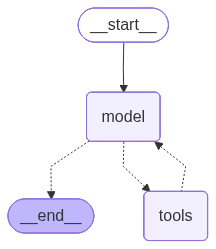

In [59]:
# Used to display images inside Jupyter notebooks (e.g., agent graphs)
from IPython.display import Image, display

# Initializes a chat-based LLM (OpenAI, Anthropic, etc. depending on config)
from langchain.chat_models import init_chat_model

# Decorator for defining tools for the agent
from langchain_core.tools import tool

# Prebuilt ReAct-style agent constructor
from langchain.agents import create_agent

from langchain_anthropic import ChatAnthropic

#!pip install langchain-google-genai

tools = [calculator]  # must be defined earlier
# ----------------------------
# SYSTEM PROMPT (agent behavior)
# ----------------------------
SYSTEM_PROMPT = """
You are a helpful arithmetic assistant who is an expert at using a calculator tool.
Return all text as plain text without using Markdown math delimiters.
"""


# ----------------------------
# LLM INITIALIZATION
# ----------------------------
model = ChatAnthropic(model="claude-sonnet-4-6", temperature=0.0)
# ----------------------------
# TOOLS (make sure calculator is defined above in notebook)
# ----------------------------
tools = [calculator]


# ----------------------------
# CREATE AGENT
# ----------------------------
agent = create_agent(model, tools, system_prompt=SYSTEM_PROMPT).with_config({"recursion_limit": 20})

# ----------------------------
# VISUALIZE AGENT GRAPH
# ----------------------------
display(
    Image(
        agent.get_graph(xray=True).draw_mermaid_png()
    )
)

In [60]:
# Create_react_agent returns a compiled graph

## 🔁 How the graph works internally

When I create an agent, LangGraph automatically builds a graph structure behind the scenes.

## This graph includes:

- A model node → decides what to do next
- A tool node → executes tool calls
- A state flow → passes messages between nodes

## 🛠️ The ToolNode

A key internal component is the ToolNode:

- It receives tool calls generated by the LLM
- Executes the required tools
- Returns the results back to the model as observations

This is what enables the “Act” part of ReAct (Reason + Act loop).

## 🚀 Invoking the agent

Once the graph is built, I can invoke the agent and:

- Send an input message
- Let the model decide whether tools are needed
- Watch the loop execute through the graph
- Receive the final response once execution completes

## 🧠 Key idea

The agent is not just a single model call — it is a graph-driven execution system where:

- Messages = state
- Model = reasoning engine
- Tools = external actions
- Graph = control flow

In [62]:
import sys; sys.path.append("notebooks")
from utils import format_messages
# Example Usage
result1 = agent.invoke({"messages": [{"role": "user", "content": "What is 3.1 * 4.2?"}]})
format_messages(result1["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 3.1 * 4.2?                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: toolu_014f4xmD6BSG7AkGQwGV7GVw                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 multiplied by 4.2 equals 13.02!                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

![Agent Diagram](assets/Invoking-the-agent.png)

Now, I will run a query and check the trace in Langsmith and check if it is correct. 
- In the metadata of LLM, we should see 'calculator' tool description,.
- The response from the model is a tool call with the arguments
- In the final call to the LLM, notice the matching tool_call_id's provided by the tool node

In [63]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 5 * 5?",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 5 * 5?                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5,                                                                                                       │
│   "b": 5                                                                                                        │
│ }                                                                                                               │
│    ID: toolu_01F2zN6Arko9JjFHc55BFjL4                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 25                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 5 * 5 = 25!                                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Accessing and Modifying State Within Tools

In LangGraph, I work with a shared state object that persists throughout the execution of the graph.
This state is strongly typed and can be accessed by every node during runtime. 
It is also useful for debugging and for resuming long-running graphs from earlier checkpoints.

When I define a graph state, I specify both:

- The data types of each field
- A reducer function that controls how updates are applied

This is especially important when multiple nodes run in parallel and try to update the same state at the same time.


## Example: AgentState

In this example, I use the default AgentState, defined in langgraph.prebuilt.chat_agent_executor.

class AgentState(TypedDict):

    """The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    remaining_steps: NotRequired[RemainingSteps]


## Key Components

### messages
- I use this to store the conversation history between the user and the LLM
- It is a sequence of BaseMessage objects from langchain_core

## Annotated type
- I use typing. Annotated to attach metadata to type hints
- Syntax: Annotated[Type, metadata1, metadata2, ...]

## add_messages reducer
- I rely on this reducer to automatically append new messages to the existing list
- This ensures message history is preserved across node updates remaining_steps
- I use this to track how many steps are left in the graph execution
- It is initialized internally using the graphs recursion_limit
- This is managed by the system and not directly exposed to the user

In [67]:
from IPython.display import JSON
from langchain_core.messages import messages_to_dict

JSON({"messages": messages_to_dict(result1["messages"])})

<IPython.core.display.JSON object>

## Custom State

In this extension, I enhance my calculator by introducing a custom state field that stores a history of all operations performed.

To do this, I:

- Add a list field in the state to track operations over time
- Define a reducer function that safely appends each new operation to this list

This ensures that:

- Every operation is recorded in sequence
- The state update remains safe even if the list is initially empty or undefined
- Multiple updates do not overwrite previous operations, especially in concurrent executions

Overall, this allows me to maintain a reliable operation history log inside the graph state for debugging, traceability, and long-running workflows.

In [68]:
from langchain.agents import AgentState
from typing import List, Annotated


def reduce_list(left: list | None, right: list | None) -> list:
    """
    Reducer function to safely merge two lists in LangGraph state.

    This function ensures that list updates in state are handled safely,
    even when values are None (which can happen during initialization or
    partial updates from different nodes).

    Args:
        left (list | None): Existing state value (previous list of ops).
        right (list | None): New incoming updates to be merged.

    Returns:
        list: A merged list containing elements from both inputs.
              None values are treated as empty lists.
    """

    # If the existing state is None or empty, treat it as an empty list
    if not left:
        left = []

    # If the incoming update is None or empty, treat it as an empty list
    if not right:
        right = []

    # Combine both lists into a single updated history
    return left + right


class CalcState(AgentState):
    """
    Custom LangGraph state for a calculator agent.

    Extends the default AgentState by adding an operation history
    tracker that records all calculator operations performed.
    """

    # List of all operations performed during execution.
    # The reducer ensures safe appending across multiple nodes/updates.
    ops: Annotated[List[str], reduce_list]

### Accessing State

When I extend my calculator to include state updates, I run into an important limitation in the tool-calling flow.

At this point:

- The LLM is responsible for generating the tool call
- The tool now expects an additional argument: state

### 🚨 The Problem

The issue is that the LLM cannot construct the state argument, because:

- It is not part of the prompt context
- It is managed internally by LangGraph at runtime
-The model only sees user input + conversation history, not execution state

So even though the tool requires state, the LLM has no way to reliably produce it.

<div style="display: flex; gap: 10px; justify-content: flex-start;">
  <img src="assets/ToolCalling-Agent.png" width="40%" />
  <img src="assets/Workflow.png" width="40%" />
  <img src="assets/Futuretools.png" width="40%" />
</div>


## 💡 The Solution: Inject State After the LLM

To solve this, the design changes the execution order:

- The LLM first generates the tool name + arguments it can see
- The system (LangGraph runtime) then injects the current state
- The tool receives a fully constructed input at execution time

This ensures:

- The LLM stays stateless with respect to hidden runtime data
- The system safely controls and supplies execution state
- Tool calls remain valid and deterministic
- 
<div style="display: flex; gap: 10px; justify-content: flex-start;">
  <img src="assets/bigflowdiagram.png" width="40%" />
    
  <img src="assets/flowdiagram.png" width="40%" />
</div>



This is done with the InjectedState annotation as shown below.

    @tool
    def calculator_wstate(
        operation: Literal["add","subtract","multiply","divide"],
        a: Union[int, float],
        b: Union[int, float],
        state: Annotated[CalcState, InjectedState],  # ← not sent to LLM
        tool_call_id: Annotated[str, InjectedToolCallId],  # ← not sent to LLM
    ) -> Union[int, float]:
    
This strips state from the description provided to the LLM
and injects it when calling the tool in ToolNode.
the tool_call_id is also included. 


In [69]:
@tool
def calculator_wstate(
    operation: Literal["add", "subtract", "multiply", "divide"],
    a: Union[int, float],
    b: Union[int, float],
    state: Annotated[CalcState, InjectedState],   # NOT sent to LLM (injected by LangGraph)
    tool_call_id: Annotated[str, InjectedToolCallId]  # NOT sent to LLM (tracks tool execution)
) -> Union[int, float]:
    """
    A calculator tool that performs arithmetic operations and updates LangGraph state.

    This tool also demonstrates:
    - Injected state access (CalcState)
    - Tool call tracking via tool_call_id
    - Returning structured updates using Command
    """

    # ------------------------------------------------------------
    # SAFETY CHECK: division by zero
    # ------------------------------------------------------------
    if operation == "divide" and b == 0:
        return {"error": "Division by zero is not allowed."}

    # ------------------------------------------------------------
    # CORE CALCULATION LOGIC
    # ------------------------------------------------------------
    if operation == "add":
        result = a + b
    elif operation == "subtract":
        result = a - b
    elif operation == "multiply":
        result = a * b
    elif operation == "divide":
        result = a / b
    else:
        result = "unknown operation"

    # ------------------------------------------------------------
    # STATE UPDATE PREPARATION
    # ------------------------------------------------------------
    # Record the operation performed for tracking/debugging
    ops = [f"({operation}, {a}, {b})"]

    # ------------------------------------------------------------
    # RETURN USING COMMAND OBJECT
    # ------------------------------------------------------------
    # Instead of returning just a value, we:
    # - Update graph state ("ops")
    # - Append a ToolMessage to conversation history
    # - Tie response to tool_call_id for traceability
    return Command(
        update={
            "ops": ops,
            "messages": [
                ToolMessage(f"{result}", tool_call_id=tool_call_id)
            ],
        }
    )

This version is what makes LangGraph powerful:

Tools are no longer just functions — they become state-aware graph operators

In [71]:
from langchain_anthropic import ChatAnthropic

# ------------------------------------------------------------
# SYSTEM PROMPT
# ------------------------------------------------------------
# Defines the behavior of the assistant.
# We explicitly instruct the model to:
# - Act as an arithmetic calculator assistant
# - Avoid Markdown math formatting for cleaner outputs
SYSTEM_PROMPT = """
You are a helpful arithmetic assistant who is an expert at using a calculator.
Return all text as plain text without Markdown math delimiters.
"""

# ------------------------------------------------------------
# MODEL INITIALIZATION
# ------------------------------------------------------------
# Using Claude Sonnet with deterministic output (temperature=0)
model = ChatAnthropic(
    model="claude-sonnet-4-6",
    temperature=0.0
)

# ------------------------------------------------------------
# TOOLS
# ------------------------------------------------------------
# Register custom tools that the agent can call.
# Here we are using a state-aware calculator tool.
tools = [calculator_wstate]

# ------------------------------------------------------------
# AGENT CREATION
# ------------------------------------------------------------
# We build a LangGraph agent that:
# - Uses the specified LLM
# - Has access to tools
# - Maintains structured state (CalcState)
agent = create_agent(
    model,
    tools,
    system_prompt=SYSTEM_PROMPT,
    state_schema=CalcState  # defines the structure of graph state
).with_config(
    {
        # --------------------------------------------------------
        # RECURSION LIMIT
        # --------------------------------------------------------
        # Controls how many reasoning/tool-execution steps
        # the agent is allowed to perform before stopping.
        "recursion_limit": 20
    }
)

In [73]:
result2 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content" : " What is 25/5?",
            }
        ],
    }
)

format_messages(result2["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│  What is 25/5?                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll calculate that for you right away!                                                                         │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "divide",                                                                                        │
│   "a": 25,                                                                                                      │
│   "b": 5                                                                                                        │
│ }                                                                                                               │
│    ID: toolu_01CpxweHfdNvkEyyFmfQVmay                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 5.0                                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 25 divided by 5 equals 5. Let me know if you have any other calculations!                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [74]:
# The OPS field is now in the response
JSON(result2)

<IPython.core.display.JSON object>

Now we will experiment and use a dual call tool.

In [77]:
result3 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 5 * 10 + 6.4 + 28?"
            }
        ],
    }
)
format_messages(result3["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is 5 * 10 + 6.4 + 28?                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll solve this step by step. First, I'll handle the multiplication (5 * 10), and since the two additions are   │
│ independent of each other, I can't do them yet. Let me start with the multiplication first!                     │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5,                                                                                                       │
│   "b": 10                                                                                                       │
│ }                                                                                                               │
│    ID: toolu_019Hc18aTVuZ6P4BQqy59DAt                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 50                                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Now I'll add 6.4 and 28 to 50. Since these additions are sequential, let me chain them together — first adding  │
│ 6.4, then 28!                                                                                                   │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 50,                                                                                                      │
│   "b": 6.4                                                                                                      │
│ }                                                                                                               │
│    ID: toolu_01QHGqmZHNtJQnXU3LmU1e7V                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 56.4                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 56.4,                                                                                                    │
│   "b": 28                                                                                                       │
│ }                                                                                                               │
│    ID: toolu_01TiUzr3qKZank3bk8JE2QDJ                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 84.4                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here's the breakdown:                                                                                           │
│                                                                                                                 │
│ 1. 5 * 10 = 50                                                                                                  │
│ 2. 50 + 6.4 = 56.4                                                                                              │
│ 3. 56.4 + 28 = 84.4                                                                                             │
│                                                                                                                 │
│ So, 5 * 10 + 6.4 + 28 = 84.4                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [78]:
JSON(result3)

<IPython.core.display.JSON object>